In [21]:
import pandas as pd
from sklearn.metrics import classification_report

### Evaluation Original
Victim:

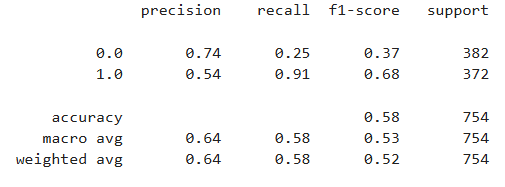

Perpetrator:

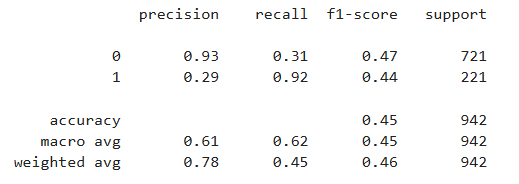

### Modificaciones post 13-03-2026
<ul>
    <li>Pasamos país a booleana (España 0, otros 1)</li>
    <li>Pasamos Etnia a booleana de verdad (está como Real)</li>
    <li>Pasamos Fugas a booleana de verdad (está como Real)</li>
    <li>Hacemos one hot encoding de porno (Pasamos los 5 estados a 5 booleanas)</li>
    <li>Si ABUSOBS1 es 0, ABUSOBS2 pasa 0</li>
    <li>Agrupamos ABUSOBS2 es 2 categorias (nunca, anualmente, mensualmente) (diaro, semanal) False es la primera, True es la segunda</li>
    <li>Hacemos one-hot encoding de ABUSOBS1 y ABUSOBS2</li>
    <li>Limpiamos género binarizada. Quitamos GENERO_BIN_1 y mantenemos GENERO_BIN_0. Renombramos a GENERO.BN. Convertimos a booleano</li>
    <li>Limpiamos Orientación sexual binarizada. Quitamos ORIENTSEX.BN_2 y mantenemos ORIENTSEX.BN_1 que renombramos por ORIENTSEX.BN_0. Convertimos a booleano</li>
    <li>Aplastamos las de conviven:</li>
    <ul>
        <li>CONVIVEN.0: True si conviven con 0 progenitores. Equivale a CONVIVEN.6, el 7 se juntó con el 6 (otros) al haber pocos.</li>
        <li>CONVIVEN.1: True si conviven con 1 progenitores. Si es True una y solo una de: CONVIVEN.1, CONVIVEN.2, CONVIVEN.3, CONVIVEN.4</li>
        <li>CONVIVEN.2: True si conviven con 2 progenitores. Si es True más de una de: CONVIVEN.1, CONVIVEN.2, CONVIVEN.3, CONVIVEN.4</li>
        <li>CONVIVEN.H: True si conviven con uno o más hermanos. Equivale a CONVIVEN.5</li>
    </ul>   
</ul>

### Afectaciones a la precisión del modelo
<ul>
    <li> Eliminamos el one hot encoding de porno (Pasamos los 5 estados a 5 booleanas)</li>
    <li> Eliminamos la asignación de ABUSO1 a ABUSO2 (Pierde entropía)</li>
    <li> Eliminamos agrupamos ABUSOBS2 es 2 categorias (Pierde entropía)</li>
    <li> Eliminamos Aplastamos las de conviven (Pierde entropía)</li>
    <ul>
        <li> Mantenemos CONVIVEN.0 y CONVIVEN.H, pero no podemos aplastar CONVIVEN.1, CONVIVEN.2, CONVIVEN.3, CONVIVEN.4 en 2 variables</li>
    </ul>
     <li> No podemos eliminar género binarizada. Seguimos con las dos variables, pero si las hemos pasado a booleano.</li>
    <li> No podemos eliminar Orientación sexual binarizada. Seguimos con las dos variables, pero si las hemos pasado a booleano.</li>
</ul>

### Réplica en perpretraror
Para mantener la consistencia, replicamos las modificaciones en el set de datos usado para entrenar y validar el predictor perpetrator.

### Construcción de predictor de la intersección
Construimos el predictor de la intersección usando un DT.<br>
Evaluación:

![image.png](attachment:abc4c462-b9f9-4b5f-aa48-375b41e61bab.png)

Construimos el predictor de la intersección usando una DNN.<br>
Evaluación:

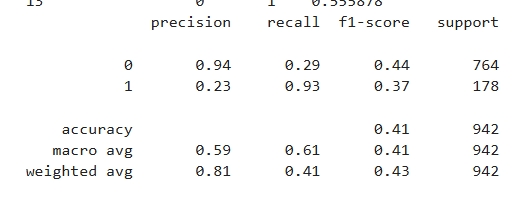

Construimos el predictor de la intersección usando un ensemble. Para evaluar la intersección, el predictor víctima (DT) debe evaluar True y el predictor perpetrator (DNN) debe evaluar True.<br>

Evaluación:

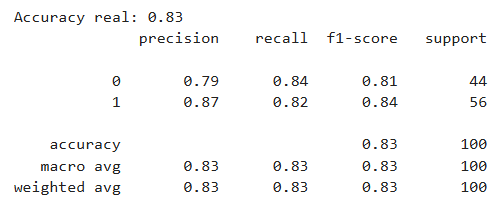

Conclusión: El predictor DNN funciona mejor que el ensemble. Hipótesis: El recall del ensemble decae debido a la combinación DT con DNN, haciendo que una DNN sin ensemble se entrene y ajuste mejor a la intersección.

### Evaluación Post cambios.


Victim, Nos mantenemos:

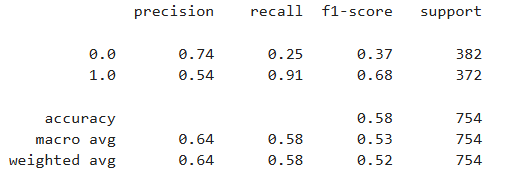

Perpetrator, subimos ligeramente:

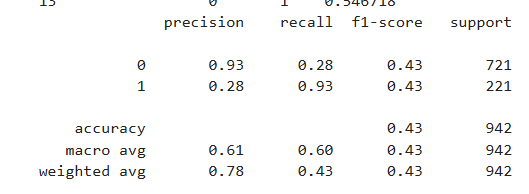

Intersección: No disponíamos de código o precisión previa, asi que se ha hecho de nuevo y no podemos comparar si hemos mejorado o empeorado.



### Preguntas post 13-03-2026
¿Tenemos acceso a la última versión del documento para aplicar los cambios revisados y aprobados?<br> Dispongo de una versión del documento pero me quiero asegurar que tenemos la última.